In [43]:
import numpy as np
import PyWSINDy_ODE.wsindy as ws
import PyWSINDy_ODE.ODE_examples as ODE_examples 
import matplotlib.pylab as plt
from scipy.integrate import solve_ivp

from agl_helpers import addNoise, recoverDynamics

True The solver successfully reached the end of the integration interval. 29.990000000000002 (3000, 7)


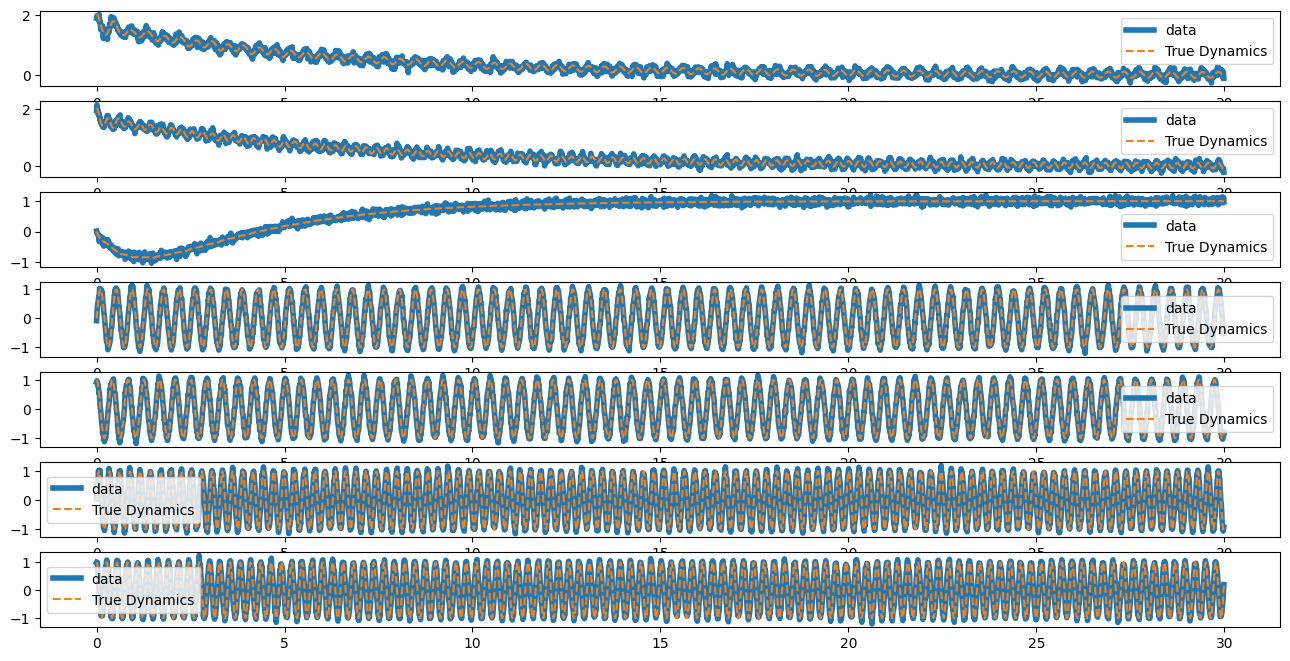

In [44]:
t_span = np.array([0,30])
t_eval = np.arange(0,30,0.01)
noise_ratio = 0.1

# extremum seeking parameters
alpha = 0.1 #dither amplitude
omega_x = 15 #x dither frequency
omega_y = 23 #y dither frequency
omega_n = 1 #high pass filter cutoff frequency
k = 3  #learning rate

#cost function parameters
qx = 0.5
qy = 0.5
f_star = 1.0

def rhs(t, z):
            
            x, y, eta, mx, cx, my, cy = z

            J = f_star - qx*x**2 - qy*y**2 #quadratic cost function
            e = J - eta

            dx = k*e*mx + alpha*omega_x*cx
            dy = k*e*my + alpha*omega_y*cy
            deta = omega_n*e

            dmx = omega_x*cx
            dcx = -omega_x*mx
            dmy = omega_y*cy
            dcy = -omega_y*my

            return np.array([dx, dy, deta, dmx, dcx, dmy, dcy])

x0 = np.array([
    2, #x initial
    2, #y initial
    0, #eta
    np.sin(omega_x*t_span[0]),
    np.cos(omega_x*t_span[0]),
    np.sin(omega_y*t_span[0]),
    np.cos(omega_y*t_span[0]),
])


sol = solve_ivp(fun=rhs, t_eval=t_eval, t_span=t_span, y0=x0, rtol=1e-6)
print(sol.success, sol.message, sol.t[-1], sol.y.T.shape)


x = sol.y.T
t = sol.t
xobs = addNoise(x=sol.y.T,noise_ratio=noise_ratio)

# plt.plot(sol.t,xobs)
fig = plt.figure(figsize=(16, 8))
c = 1
n = xobs.shape[1]
for d in range(n):
    plt.subplot(n, 1, c)
    plt.plot(t, xobs[:, d], label = "data", linewidth = 4)
    plt.plot(t, x[:, d], "--", label = 'True Dynamics',)
    c = c + 1
    plt.legend()

In [45]:
WSINDy_model = ws.wsindy(polys=np.arange(0, 2),ld=0.05
                         )

#Uniform
WSINDy_model.getWSindyUniform(xobs, t, L = 30, overlap=0.7)

t_ws, WSINDy_sim = WSINDy_model.simulate(t_span = [t[0],t[-1]], t_eval = t, x0 = xobs[0,:])

recoverDynamics(WSINDy_model)

True The solver successfully reached the end of the integration interval. 29.990000000000002 (3000, 7)
dx0/dt = (1.4856)x4 + (0.1754)x3 + (0.1389)x1 + (-0.3023)x0
dx1/dt = -0.0751 + (2.2190)x6 + (0.2138)x5 + (-0.0742)x3 + (0.0690)x2 + (-0.6257)x1 + (0.5897)x0
dx2/dt = 0.5180 + (0.0912)x6 + (-0.4625)x5 + (0.6058)x3 + (-0.5114)x2 + (4.9958)x1 + (-5.6472)x0
dx3/dt = 0.3127 + (-0.1199)x6 + (14.7332)x4 + (-0.2397)x2 + (0.1891)x1 + (-0.5699)x0
dx4/dt = (0.1507)x6 + (-14.8105)x3 + (-0.2519)x1 + (0.2897)x0
dx5/dt = -0.3213 + (21.6962)x6 + (0.7859)x5 + (-0.0580)x4 + (-0.2092)x3 + (0.2952)x2 + (-1.1085)x1 + (1.5106)x0
dx6/dt = 0.0666 + (-0.6271)x6 + (-22.0792)x5 + (-0.0866)x3 + (-0.0854)x2 + (-0.7573)x1 + (0.7198)x0


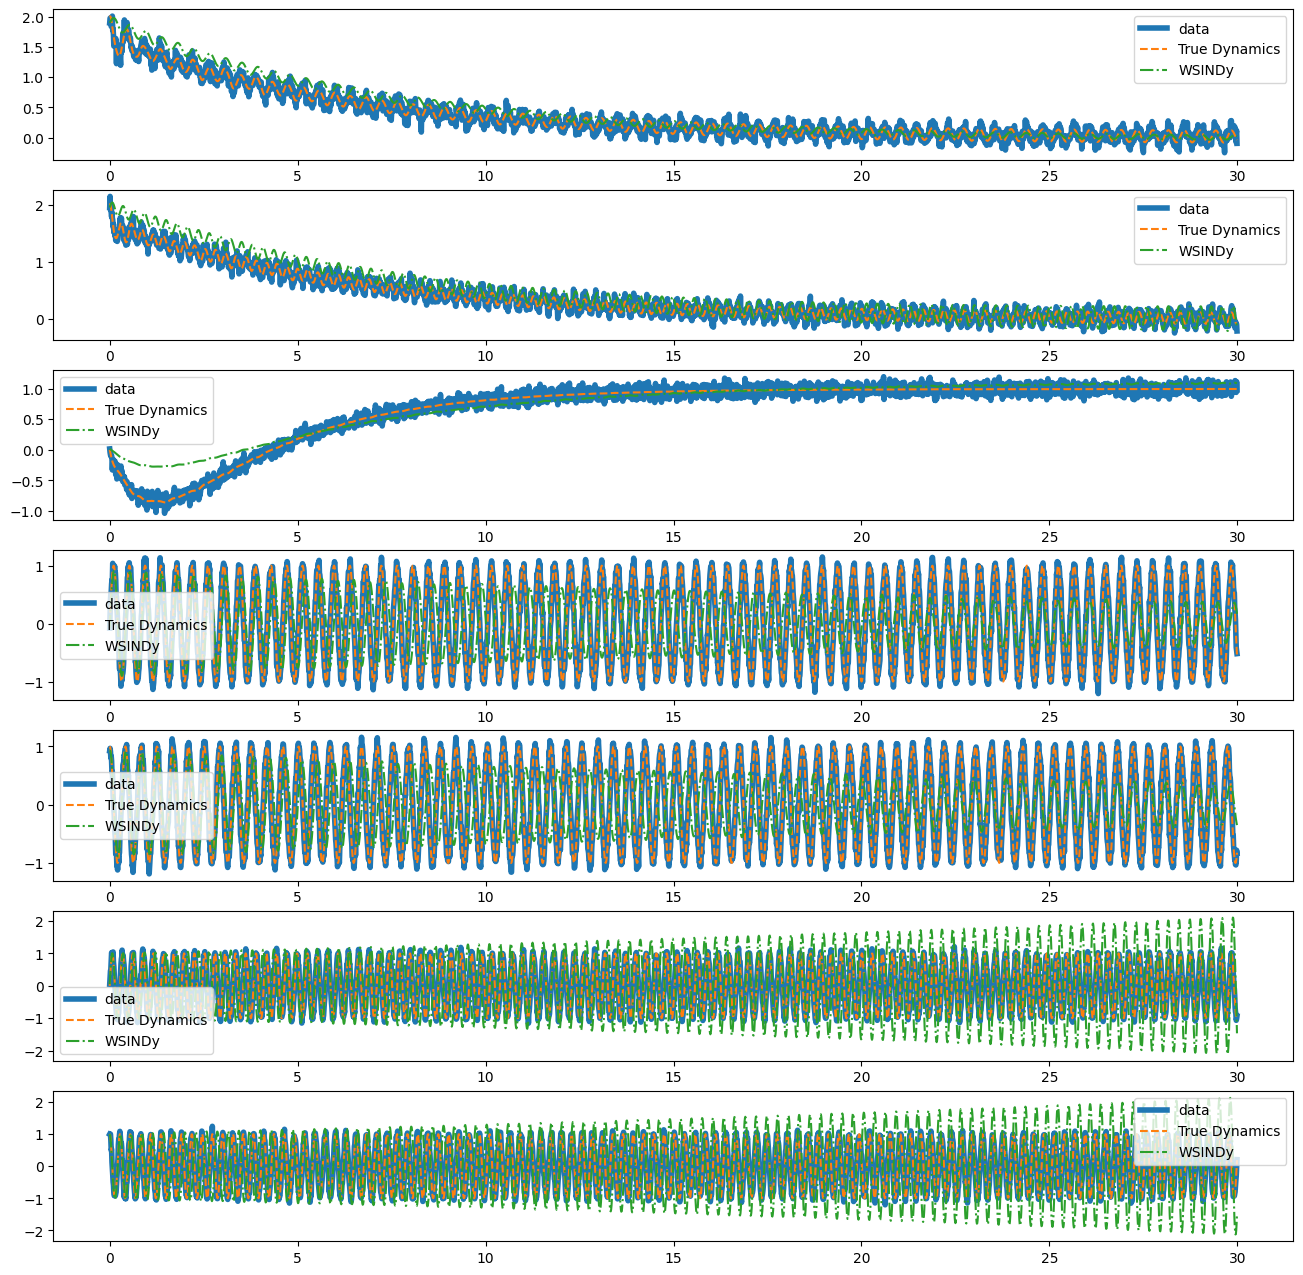

In [46]:
fig = plt.figure(figsize=(16, 16))
c = 1
n = xobs.shape[1]
for d in range(n):
    plt.subplot(n, 1, c)
    plt.plot(t, xobs[:, d], label = "data", linewidth = 4)
    plt.plot(t, x[:, d], linestyle = "--", label = 'True Dynamics',) #marker = 'o', markevery=300)
    plt.plot(t_ws, WSINDy_sim[:, d], linestyle='dashdot', label = 'WSINDy') #marker = 'v', markevery = 200)
    
    c = c + 1
    plt.legend()

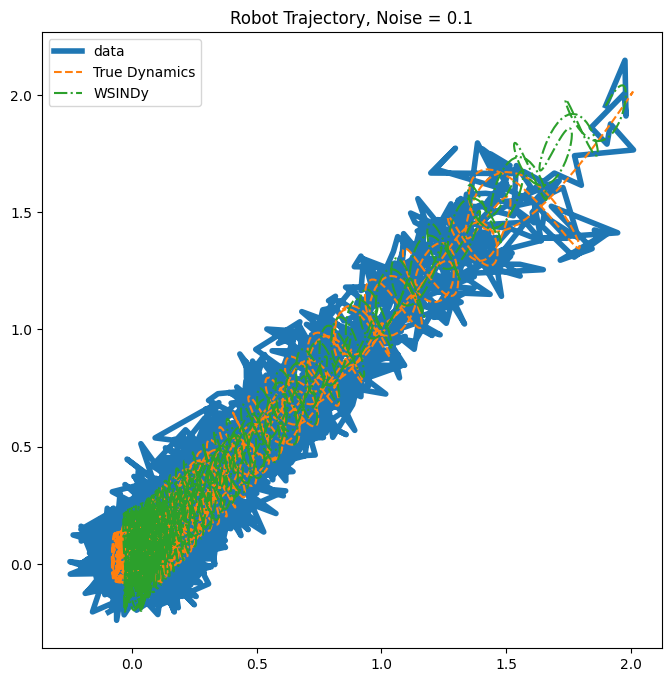

In [47]:
fig = plt.figure(figsize=(8, 8))
c = 1
n = xobs.shape[1]
plt.title(f"Robot Trajectory, Noise = {noise_ratio}")

plt.plot(xobs[:, 0], xobs[:, 1], label = "data", linewidth = 4)
plt.plot(x[:, 0], x[:, 1], linestyle = "--", label = 'True Dynamics',) #marker = 'o', markevery=300)
plt.plot(WSINDy_sim[:, 0], WSINDy_sim[:, 1], linestyle='dashdot', label = 'WSINDy') #marker = 'v', markevery = 200)
    
c = c + 1
plt.legend()

True The solver successfully reached the end of the integration interval. 29.990000000000002 (3000, 7)
True The solver successfully reached the end of the integration interval. 29.990000000000002 (3000, 7)
True The solver successfully reached the end of the integration interval. 29.990000000000002 (3000, 7)
True The solver successfully reached the end of the integration interval. 29.990000000000002 (3000, 7)
True The solver successfully reached the end of the integration interval. 29.990000000000002 (3000, 7)


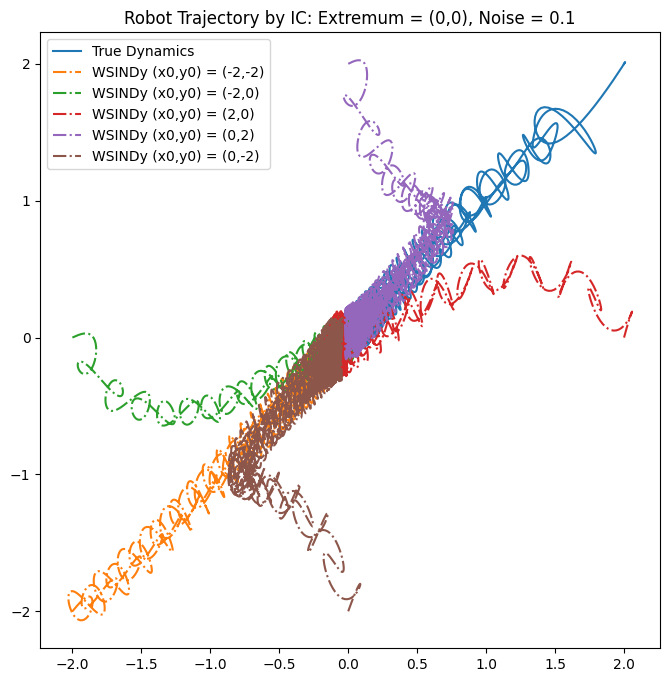

In [48]:
x0 = np.array([
    -2, #x initial
    -2, #y initial
    0, #eta
    np.sin(omega_x*t_span[0]),
    np.cos(omega_x*t_span[0]),
    np.sin(omega_y*t_span[0]),
    np.cos(omega_y*t_span[0]),
])
t_ws, WSINDy_sim = WSINDy_model.simulate(t_span = [t[0],t[-1]], t_eval = t, x0 = x0)


fig = plt.figure(figsize=(8, 8))
c = 1
n = xobs.shape[1]

# plt.plot(xobs[:, 0], xobs[:, 1], label = "data", linewidth = 4)
plt.title(f"Robot Trajectory by IC: Extremum = (0,0), Noise = {noise_ratio}")

plt.plot(x[:, 0], x[:, 1], label = 'True Dynamics',) #marker = 'o', markevery=300)
plt.plot(WSINDy_sim[:, 0], WSINDy_sim[:, 1], linestyle='dashdot', label = 'WSINDy (x0,y0) = (-2,-2)') #marker = 'v', markevery = 200)
x0 = np.array([
    -2, #x initial
    0, #y initial
    0, #eta
    np.sin(omega_x*t_span[0]),
    np.cos(omega_x*t_span[0]),
    np.sin(omega_y*t_span[0]),
    np.cos(omega_y*t_span[0]),
])
t_ws, WSINDy_sim = WSINDy_model.simulate(t_span = [t[0],t[-1]], t_eval = t, x0 = x0)
plt.plot(WSINDy_sim[:, 0], WSINDy_sim[:, 1], linestyle='dashdot', label = 'WSINDy (x0,y0) = (-2,0)')
x0 = np.array([
    2, #x initial
    0, #y initial
    0, #eta
    np.sin(omega_x*t_span[0]),
    np.cos(omega_x*t_span[0]),
    np.sin(omega_y*t_span[0]),
    np.cos(omega_y*t_span[0]),
])
t_ws, WSINDy_sim = WSINDy_model.simulate(t_span = [t[0],t[-1]], t_eval = t, x0 = x0)
plt.plot(WSINDy_sim[:, 0], WSINDy_sim[:, 1], linestyle='dashdot', label = 'WSINDy (x0,y0) = (2,0)')

x0 = np.array([
    0, #x initial
    2, #y initial
    0, #eta
    np.sin(omega_x*t_span[0]),
    np.cos(omega_x*t_span[0]),
    np.sin(omega_y*t_span[0]),
    np.cos(omega_y*t_span[0]),
])
t_ws, WSINDy_sim = WSINDy_model.simulate(t_span = [t[0],t[-1]], t_eval = t, x0 = x0)
plt.plot(WSINDy_sim[:, 0], WSINDy_sim[:, 1], linestyle='dashdot', label = 'WSINDy (x0,y0) = (0,2)')
x0 = np.array([
    0, #x initial
    -2, #y initial
    0, #eta
    np.sin(omega_x*t_span[0]),
    np.cos(omega_x*t_span[0]),
    np.sin(omega_y*t_span[0]),
    np.cos(omega_y*t_span[0]),
])
t_ws, WSINDy_sim = WSINDy_model.simulate(t_span = [t[0],t[-1]], t_eval = t, x0 = x0)
plt.plot(WSINDy_sim[:, 0], WSINDy_sim[:, 1], linestyle='dashdot', label = 'WSINDy (x0,y0) = (0,-2)')

plt.legend()